In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset/Yellow rust/Yellow_rust762.jpg
/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset/Yellow rust/Yellow_rust777.jpg
/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset/Yellow rust/Yellow_rust1022.jpg
/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset/Yellow rust/Yellow_rust1024.jpg
/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset/Yellow rust/Yellow_rust811.jpg
/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset/Yellow rust/Yellow_rust617.jpg
/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset/Yellow rust/Yellow_rust214.jpg
/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset/Yellow rust/Yellow_rust251.jpg
/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset/Yellow rust/Yellow_rust1139.jpg
/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset/Yellow rust/Yellow_rust547.jpg
/kaggle/input/dat

In [2]:
import os

# Check all 4 dataset paths
datasets = [
    "/kaggle/input/datasets/jawadali1045/20k-multi-class-crop-disease-images",
    "/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease",
    "/kaggle/input/datasets/shadabhussain/cgiar-computer-vision-for-crop-disease",
    "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases"
]

for ds in datasets:
    print(f"\n📁 {ds}")
    if os.path.exists(ds):
        for root, dirs, files in os.walk(ds):
            level = root.replace(ds, '').count(os.sep)
            indent = '  ' * level
            print(f"{indent}📂 {os.path.basename(root)}/ ({len(files)} files)")
            if level > 2:  # don't go too deep
                break
    else:
        print("  ❌ Not found — check dataset name")


📁 /kaggle/input/datasets/jawadali1045/20k-multi-class-crop-disease-images
📂 20k-multi-class-crop-disease-images/ (0 files)
  📂 Validation/ (0 files)
    📂 RedRust sugarcane/ (31 files)
    📂 Healthy Maize/ (275 files)
    📂 Wheat___Yellow_Rust/ (19 files)
    📂 Tungro/ (9 files)
    📂 Wheat mite/ (38 files)
    📂 Anthracnose on Cotton/ (10 files)
    📂 Healthy Wheat/ (33 files)
    📂 Cotton Aphid/ (287 files)
    📂 Common_Rust/ (18 files)
    📂 American Bollworm on Cotton/ (30 files)
    📂 Yellow Rust Sugarcane/ (4 files)
    📂 Flag Smut/ (24 files)
    📂 Wheat scab/ (23 files)
    📂 Army worm/ (351 files)
    📂 cotton whitefly/ (45 files)
    📂 Bacterial Blight in cotton/ (284 files)
    📂 Wheat leaf blight/ (35 files)
    📂 Healthy cotton/ (176 files)
    📂 Wilt/ (419 files)
    📂 bollrot on Cotton/ (2 files)
    📂 Rice Blast/ (44 files)
    📂 Becterial Blight in Rice/ (22 files)
    📂 cotton mealy bug/ (58 files)
    📂 maize ear rot/ (18 files)
    📂 Wheat Stem fly/ (62 files)
    

In [3]:
import os
import shutil
import random
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import defaultdict

random.seed(42)
np.random.seed(42)
print("✅ Imports done")

✅ Imports done


In [4]:
# Exact folder names from YOUR datasets → standard class name
WHEAT_CLASS_MAP = {
    # ── HEALTHY ──────────────────────────────────────
    "healthy"                  : "healthy",
    "healthy wheat"            : "healthy",
    "wheat___healthy"          : "healthy",

    # ── YELLOW RUST ──────────────────────────────────
    "yellow rust"              : "yellow_rust",
    "wheat___yellow_rust"      : "yellow_rust",

    # ── BROWN / LEAF RUST ────────────────────────────
    "brown rust"               : "brown_rust",
    "wheat brown leaf rust"    : "brown_rust",

    # ── STEM / BLACK RUST ────────────────────────────
    "stem_rust"                : "stem_rust",
    "wheat black rust"         : "stem_rust",

    # ── LOOSE SMUT ───────────────────────────────────
    "loose smut"               : "loose_smut",
    "flag smut"                : "loose_smut",   # merging smuts together
    "leaf smut"                : "loose_smut",

    # ── SEPTORIA ─────────────────────────────────────
    "septoria"                 : "septoria",
    "wheat leaf blight"        : "septoria",     # similar symptom

    # ── POWDERY MILDEW ───────────────────────────────
    "wheat powdery mildew"     : "powdery_mildew",

    # ── SCAB / BLIGHT ────────────────────────────────
    "wheat scab"               : "scab",
}

VALID_EXT = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

print(f"✅ {len(set(WHEAT_CLASS_MAP.values()))} wheat classes defined:")
for c in sorted(set(WHEAT_CLASS_MAP.values())):
    print(f"   🌾 {c}")

✅ 8 wheat classes defined:
   🌾 brown_rust
   🌾 healthy
   🌾 loose_smut
   🌾 powdery_mildew
   🌾 scab
   🌾 septoria
   🌾 stem_rust
   🌾 yellow_rust


In [5]:
DATASET_PATHS = [
    "/kaggle/input/datasets/jawadali1045/20k-multi-class-crop-disease-images",
    "/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease",
    "/kaggle/input/datasets/shadabhussain/cgiar-computer-vision-for-crop-disease",
    "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases",
]

def collect_wheat_images(dataset_paths, class_map):
    class_images = defaultdict(list)
    skipped_folders = []

    for ds_path in dataset_paths:
        if not os.path.exists(ds_path):
            print(f"⚠️  Not found: {ds_path}")
            continue

        for root, dirs, files in os.walk(ds_path):
            folder = os.path.basename(root).lower().strip()
            imgs = [
                os.path.join(root, f)
                for f in files
                if Path(f).suffix in VALID_EXT
            ]
            if not imgs:
                continue

            if folder in class_map:
                std_class = class_map[folder]
                class_images[std_class].extend(imgs)
            else:
                skipped_folders.append(f"{folder} ({len(imgs)} imgs)")

    print("\n⚠️  Skipped (non-wheat) folders:")
    for s in sorted(set(skipped_folders)):
        print(f"   ↳ {s}")

    return dict(class_images)

class_images = collect_wheat_images(DATASET_PATHS, WHEAT_CLASS_MAP)

print("\n📊 Raw Collection:")
print(f"{'Class':<20} {'Images':>8}")
print("─" * 30)
for cls, imgs in sorted(class_images.items()):
    flag = "✅" if len(imgs) >= 500 else "⚠️ "
    print(f"{flag} {cls:<18} {len(imgs):>8}")
print(f"\n{'TOTAL':<20} {sum(len(v) for v in class_images.values()):>8}")


⚠️  Skipped (non-wheat) folders:
   ↳ american bollworm on cotton (30 imgs)
   ↳ american bollworm on cotton (56 imgs)
   ↳ anthracnose on cotton (10 imgs)
   ↳ anthracnose on cotton (29 imgs)
   ↳ aphid (903 imgs)
   ↳ aphid_test (50 imgs)
   ↳ aphid_valid (20 imgs)
   ↳ army worm (351 imgs)
   ↳ army worm (40 imgs)
   ↳ bacterial blight in cotton (284 imgs)
   ↳ bacterial_blight in cotton (489 imgs)
   ↳ becterial blight in rice (1584 imgs)
   ↳ becterial blight in rice (22 imgs)
   ↳ black rust (576 imgs)
   ↳ black_rust_test (50 imgs)
   ↳ black_rust_valid (20 imgs)
   ↳ blast (647 imgs)
   ↳ blast_test (50 imgs)
   ↳ blast_test_valid (20 imgs)
   ↳ bollrot on cotton (2 imgs)
   ↳ bollworm on cotton (10 imgs)
   ↳ bollworm on cotton (22 imgs)
   ↳ brown_rust_test (50 imgs)
   ↳ brown_rust_valid (20 imgs)
   ↳ brownspot (1640 imgs)
   ↳ brownspot (9 imgs)
   ↳ common root rot (614 imgs)
   ↳ common_root_rot_test (50 imgs)
   ↳ common_root_rot_valid (20 imgs)
   ↳ common_rust (1306 

In [6]:
def validate_image(path):
    try:
        img = Image.open(path)
        img.verify()
        img = Image.open(path)
        w, h = img.size
        return w >= 64 and h >= 64
    except:
        return False

print("🔍 Validating images (removing corrupt/tiny)...")
validated = {}
for cls, images in class_images.items():
    valid = [p for p in tqdm(images, desc=cls) if validate_image(p)]
    validated[cls] = valid
    print(f"   {cls}: {len(images)} → {len(valid)} valid")

print(f"\n✅ Total valid images: {sum(len(v) for v in validated.values())}")

🔍 Validating images (removing corrupt/tiny)...


yellow_rust:   0%|          | 0/2807 [00:00<?, ?it/s]

   yellow_rust: 2807 → 2671 valid


healthy:   0%|          | 0/2915 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


...

   brown_rust: 2632 → 2410 valid


stem_rust:   0%|          | 0/528 [00:00<?, ?it/s]

   stem_rust: 528 → 528 valid


powdery_mildew:   0%|          | 0/211 [00:00<?, ?it/s]

   powdery_mildew: 211 → 211 valid

✅ Total valid images: 11710


In [7]:
import cv2
import albumentations as A

# ── Target images per class ──────────────────────
TARGET = 1200

# ── Augmentation pipeline for real-world farming ─
augmentor = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.5, 1.0)),  # ← fix: size as tuple
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=45, p=0.6),
    A.MotionBlur(blur_limit=7, p=0.4),
    A.GaussianBlur(blur_limit=5, p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.5,
        contrast_limit=0.5, p=0.6),
    A.RandomShadow(p=0.3),
    A.HueSaturationValue(
        hue_shift_limit=20,
        sat_shift_limit=40,
        val_shift_limit=30, p=0.5),
    A.GaussNoise(var_limit=(20, 80), p=0.4),
    A.ISONoise(p=0.3),
    A.Downscale(scale_min=0.5, scale_max=0.9, p=0.3),
    A.CoarseDropout(
        max_holes=8, max_height=25,
        max_width=25, p=0.3),
    A.CLAHE(p=0.2),
])
OUTPUT_DIR = "/kaggle/working/wheat_dataset"

def augment_and_save(images, cls, split, dest_dir, target_count):
    dest_dir = Path(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)

    # Copy original images first
    for i, src in enumerate(images):
        ext = Path(src).suffix.lower()
        shutil.copy2(src, dest_dir / f"{cls}_{split}_{i:05d}{ext}")

    # Augment until we reach target
    aug_count = 0
    needed = target_count - len(images)
    if needed <= 0:
        return

    pbar = tqdm(total=needed, desc=f"Augmenting {cls}/{split}")
    while aug_count < needed:
        src = random.choice(images)
        try:
            img = cv2.imread(src)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            augmented = augmentor(image=img)["image"]
            save_path = dest_dir / f"{cls}_{split}_aug_{aug_count:05d}.jpg"
            cv2.imwrite(str(save_path),
                        cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))
            aug_count += 1
            pbar.update(1)
        except:
            continue
    pbar.close()

# ── Split ratios ─────────────────────────────────
SPLITS = {"train": 0.70, "val": 0.15, "test": 0.15}
summary = {}

for cls, images in validated.items():
    print(f"\n📂 Processing: {cls} ({len(images)} images)")

    # Remove duplicates
    seen, unique = set(), []
    for p in images:
        name = os.path.basename(p)
        if name not in seen:
            seen.add(name)
            unique.append(p)

    random.shuffle(unique)
    n = len(unique)
    n_train = int(n * SPLITS["train"])
    n_val   = int(n * SPLITS["val"])

    split_data = {
        "train" : unique[:n_train],
        "val"   : unique[n_train:n_train + n_val],
        "test"  : unique[n_train + n_val:]
    }

    # Augment ONLY train split to reach TARGET
    train_target = int(TARGET * SPLITS["train"])   # ~900
    val_target   = int(TARGET * SPLITS["val"])     # ~180
    # test stays real — never augment test data!

    for split, paths in split_data.items():
        dest = f"{OUTPUT_DIR}/{split}/{cls}"
        if split == "train":
            augment_and_save(paths, cls, split, dest, train_target)
        elif split == "val":
            augment_and_save(paths, cls, split, dest, val_target)
        else:
            # test — copy only real images, no augmentation
            Path(dest).mkdir(parents=True, exist_ok=True)
            for i, src in enumerate(paths):
                ext = Path(src).suffix.lower()
                shutil.copy2(src, f"{dest}/{cls}_test_{i:05d}{ext}")

    summary[cls] = {
        "train" : len(os.listdir(f"{OUTPUT_DIR}/train/{cls}")),
        "val"   : len(os.listdir(f"{OUTPUT_DIR}/val/{cls}")),
        "test"  : len(os.listdir(f"{OUTPUT_DIR}/test/{cls}")),
    }

/tmp/ipykernel_55/2408854603.py:23: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(20, 80), p=0.4),
/tmp/ipykernel_55/2408854603.py:25: UserWarning: Argument(s) 'scale_min, scale_max' are not valid for transform Downscale
  A.Downscale(scale_min=0.5, scale_max=0.9, p=0.3),
/tmp/ipykernel_55/2408854603.py:26: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(



📂 Processing: yellow_rust (2671 images)

📂 Processing: healthy (2915 images)

📂 Processing: loose_smut (1186 images)


Augmenting loose_smut/train:   0%|          | 0/143 [00:00<?, ?it/s]

Augmenting loose_smut/val:   0%|          | 0/31 [00:00<?, ?it/s]


📂 Processing: scab (118 images)


...

Augmenting stem_rust/train:   0%|          | 0/523 [00:00<?, ?it/s]

Augmenting stem_rust/val:   0%|          | 0/113 [00:00<?, ?it/s]


📂 Processing: powdery_mildew (211 images)


Augmenting powdery_mildew/train:   0%|          | 0/693 [00:00<?, ?it/s]

Augmenting powdery_mildew/val:   0%|          | 0/149 [00:00<?, ?it/s]


FINAL DATASET SUMMARY
Class                   Train      Val     Test    Total
----------------------------------------------------
brown_rust               1628      348      350     2326
healthy                  1948      417      419     2784
loose_smut                840      180      150     1170
powdery_mildew            840      180       33     1053
scab                      840      180       19     1039
septoria                 1169      250      252     1671
stem_rust                 840      180       69     1089
yellow_rust              1803      386      387     2576

GRAND TOTAL                                                 13708


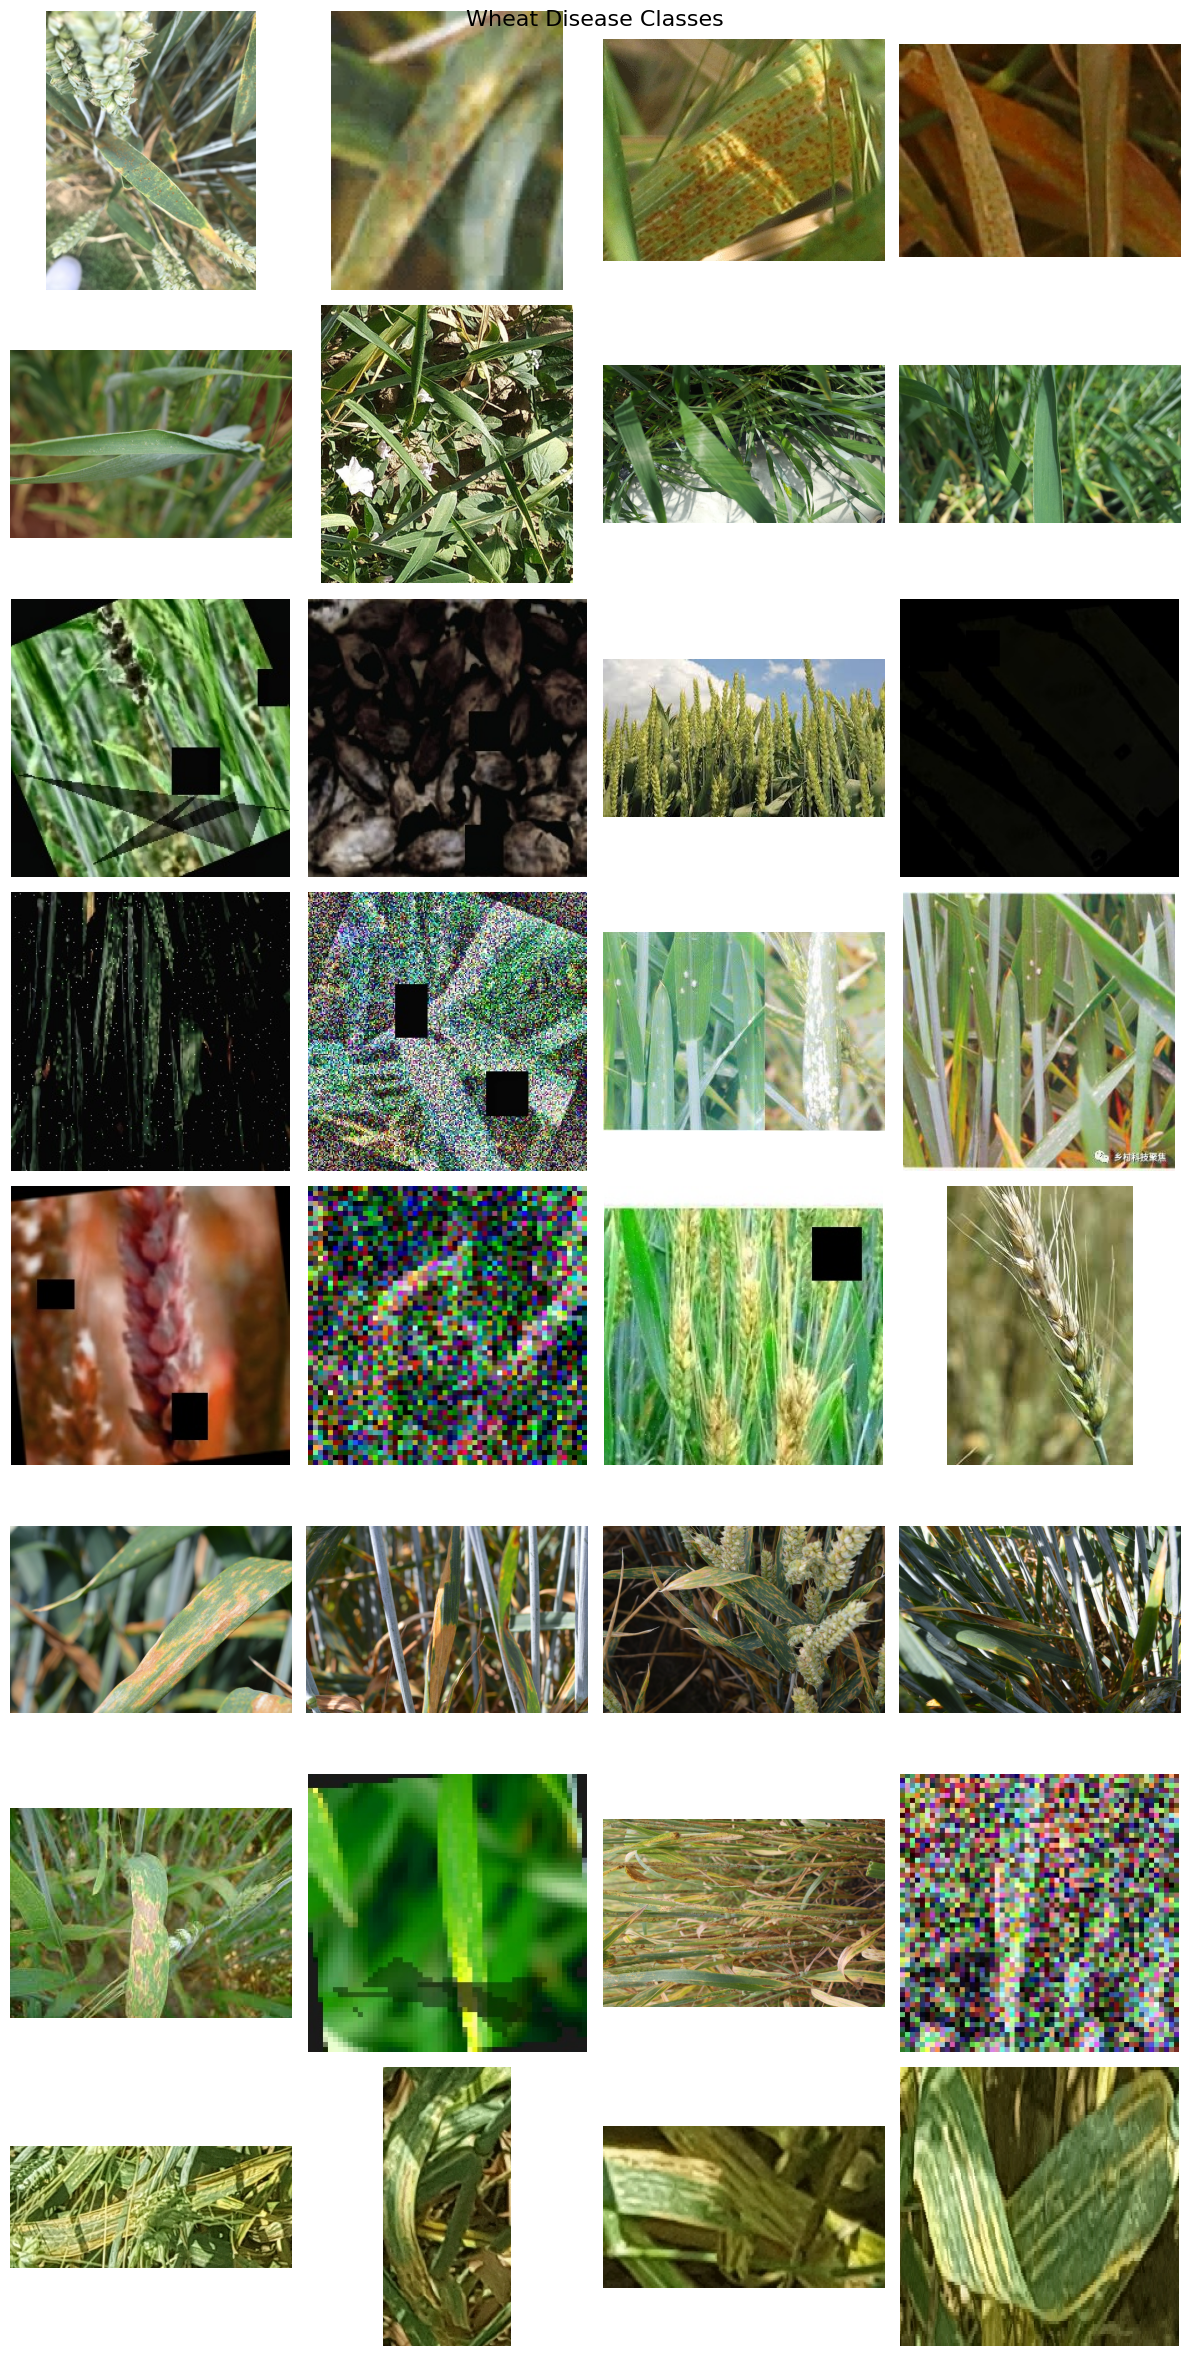

Visualization saved!


In [8]:
from matplotlib.figure import Figure

# ── Summary Table ─────────────────────────────────
print("\nFINAL DATASET SUMMARY")
print(f"{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 52)
grand = 0
for cls, counts in sorted(summary.items()):
    t = sum(counts.values())
    grand += t
    print(f"{cls:<20} {counts['train']:>8} {counts['val']:>8} {counts['test']:>8} {t:>8}")
print(f"\n{'GRAND TOTAL':<20} {grand:>44}")

# ── Visualize samples ─────────────────────────────
def safe_imread(path):
    """Read image safely, return None if corrupt."""
    try:
        img = Image.open(path).convert("RGB")
        return np.array(img)
    except:
        return None

classes = sorted(os.listdir(f"{OUTPUT_DIR}/train"))
n_samples = 4

fig, axes = plt.subplots(len(classes), n_samples,
                          figsize=(n_samples * 3, len(classes) * 3))
fig.suptitle("Wheat Disease Classes", fontsize=16)  # no emoji

for i, cls in enumerate(classes):
    cls_dir = f"{OUTPUT_DIR}/train/{cls}"
    all_imgs = os.listdir(cls_dir)
    random.shuffle(all_imgs)

    shown = 0
    for img_name in all_imgs:
        if shown >= n_samples:
            break
        img = safe_imread(f"{cls_dir}/{img_name}")
        if img is None:
            continue  # skip corrupt
        axes[i][shown].imshow(img)
        axes[i][shown].axis("off")
        if shown == 0:
            axes[i][shown].set_ylabel(cls, fontsize=9,
                                       rotation=0, labelpad=90, va="center")
        shown += 1

plt.tight_layout()
plt.savefig("/kaggle/working/samples.png", bbox_inches="tight", dpi=100)
plt.show()
print("Visualization saved!")

In [9]:
!pip install timm -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm.notebook import tqdm
import json, os, copy

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")
print(f"✅ timm version: {timm.__version__}")

✅ Using device: cuda
✅ timm version: 1.0.24


In [10]:
OUTPUT_DIR = "/kaggle/working/wheat_dataset"

# ── Transforms ───────────────────────────────────────────
# Train: light augmentation (heavy aug already done on disk)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]),
])

# Val & Test: no augmentation — clean evaluation
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]),
])

# ── Datasets ─────────────────────────────────────────────
train_dataset = datasets.ImageFolder(
    f"{OUTPUT_DIR}/train", transform=train_transform)
val_dataset   = datasets.ImageFolder(
    f"{OUTPUT_DIR}/val",   transform=eval_transform)
test_dataset  = datasets.ImageFolder(
    f"{OUTPUT_DIR}/test",  transform=eval_transform)

# ── Loaders ──────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset, batch_size=32,
    shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(
    val_dataset,   batch_size=32,
    shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(
    test_dataset,  batch_size=32,
    shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"✅ Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"   Train : {len(train_dataset):,} images")
print(f"   Val   : {len(val_dataset):,} images")
print(f"   Test  : {len(test_dataset):,} images")

✅ Classes (8): ['brown_rust', 'healthy', 'loose_smut', 'powdery_mildew', 'scab', 'septoria', 'stem_rust', 'yellow_rust']
   Train : 9,908 images
   Val   : 2,121 images
   Test  : 1,679 images


In [11]:
def build_model(num_classes, device):
    model = timm.create_model(
        "tf_efficientnetv2_s",
        pretrained=True,
        num_classes=num_classes,
        drop_rate=0.3,          # ← added dropout
        drop_path_rate=0.2      # ← added stochastic depth
    )
    model = model.to(device)
    return model

model = build_model(NUM_CLASSES, DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model: tf_efficientnetv2_s")
print(f"   Total params    : {total:,}")
print(f"   Trainable params: {trainable:,}")

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

✅ Model: tf_efficientnetv2_s
   Total params    : 20,187,736
   Trainable params: 20,187,736


In [12]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001, path="best_model.pt"):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, val_acc, model):
        if self.best_score is None or val_acc > self.best_score + self.min_delta:
            self.best_score = val_acc
            self.counter    = 0
            torch.save(model.state_dict(), self.path)
            print(f"   💾 Model saved (val_acc: {val_acc:.4f})")
        else:
            self.counter += 1
            print(f"   ⏳ No improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.stop = True
                print(f"   🛑 Early stopping triggered!")

# ── Class-weighted loss to handle imbalance ──────────────
def get_class_weights(dataset, device):
    counts = np.zeros(len(dataset.classes))
    for _, label in dataset.samples:
        counts[label] += 1
    weights = 1.0 / counts
    weights = weights / weights.sum() * len(weights)
    return torch.FloatTensor(weights).to(device)

weights    = get_class_weights(train_dataset, DEVICE)
criterion  = nn.CrossEntropyLoss(weight=weights)

print(f"✅ Class weights:")
for cls, w in zip(CLASS_NAMES, weights.cpu()):
    print(f"   {cls:<20} {w:.4f}")

✅ Class weights:
   brown_rust           0.6732
   healthy              0.5626
   loose_smut           1.3047
   powdery_mildew       1.3047
   scab                 1.3047
   septoria             0.9375
   stem_rust            1.3047
   yellow_rust          0.6079


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in tqdm(loader, desc="Training", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total


def run_training(model, train_loader, val_loader,
                 criterion, device, epochs=100, lr=1e-3):

    # ── Phase 1: Train head only (5 epochs) ──────────────
    print("=" * 55)
    print("PHASE 1: Training classifier head only (5 epochs)")
    print("=" * 55)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

    optimizer = AdamW(model.classifier.parameters(), lr=lr)

    for epoch in range(5):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc = evaluate(
            model, val_loader, criterion, device)
        print(f"Epoch {epoch+1:02d}/5 | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

    # ── Phase 2: Full fine-tune ───────────────────────────
    print("\n" + "=" * 55)
    print("PHASE 2: Full fine-tuning all layers")
    print("=" * 55)

    for param in model.parameters():
        param.requires_grad = True

    optimizer = AdamW([
        {"params": model.classifier.parameters(), "lr": lr},
        {"params": [p for n, p in model.named_parameters()
                    if "classifier" not in n],  "lr": lr / 10}
    ], weight_decay=1e-4)

    scheduler     = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    early_stopper = EarlyStopping(
        patience=10,
        path="/kaggle/working/best_model.pt")

    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   []}

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc = evaluate(
            model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)

        print(f"Epoch {epoch+1:03d}/{epochs} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

        early_stopper(vl_acc, model)
        if early_stopper.stop:
            print(f"\nBest Val Acc: {early_stopper.best_score:.4f}")
            break

    return history


# ── RUN ──────────────────────────────────────────────────
history = run_training(
    model, train_loader, val_loader,
    criterion, DEVICE,
    epochs=100,
    lr=3e-4)   # ← lower LR from 1e-3 to 3e-4

PHASE 1: Training classifier head only (5 epochs)


Training:   0%|          | 0/310 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


Evaluating:   0%|          | 0/67 [00:00<?, ?it/s]

Epoch 01/5 | Train Loss: 7.5468 Acc: 0.1847 | Val Loss: 3.9603 Acc: 0.3187


...

Training:   0%|          | 0/310 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


Evaluating:   0%|          | 0/67 [00:00<?, ?it/s]

Epoch 035/100 | Train Loss: 0.0771 Acc: 0.9742 | Val Loss: 0.2352 Acc: 0.9321
   💾 Model saved (val_acc: 0.9321)


Training:   0%|          | 0/310 [00:00<?, ?it/s]

In [ ]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"],   label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"],   label="Val Acc")
    axes[1].axhline(y=0.97, color="red",
                    linestyle="--", label="97% target")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=100)
    plt.show()

plot_history(history)

In [ ]:
def final_evaluation(model, test_loader, class_names, device):
    # Load best saved weights
    model.load_state_dict(
        torch.load("/kaggle/working/best_model.pt",
                   map_location=device))
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc="Testing"):
            imgs   = imgs.to(device)
            preds  = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # ── Classification Report ─────────────────────────
    print("\nCLASSIFICATION REPORT")
    print("(* = limited test data, interpret carefully)")
    print("-" * 60)
    report = classification_report(
        all_labels, all_preds,
        target_names=class_names)
    print(report)

    # Flag limited classes
    limited = ["scab", "powdery_mildew"]
    for cls in limited:
        if cls in class_names:
            print(f"⚠️  {cls}: only limited test images — treat result cautiously")

    # ── Confusion Matrix ──────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues")
    plt.title("Confusion Matrix — Test Set")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("/kaggle/working/confusion_matrix.png", dpi=100)
    plt.show()

    overall_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nOverall Test Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")

final_evaluation(model, test_loader, CLASS_NAMES, DEVICE)
